In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from lifelines import CoxPHFitter
import warnings

In [10]:
# Suppress warnings during stochastic search
warnings.filterwarnings("ignore")

In [11]:
class FPCoxOptimizer:
    def __init__(self, df, covariates, duration_col, event_col, penalizer=0.01):
        """
        Initializes the optimizer for any given dataset.
        """
        self.covariates = covariates
        self.duration_col = duration_col
        self.event_col = event_col
        self.penalizer = penalizer
        self.power_set = [None, -3, -2.5, -2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]
        
        # Preprocess DataFrame (ensures floats and positive values)
        self.df = self._preprocess_positive(df, covariates)
        
        # State variables for optimization
        self.evaluation_cache = {}
        self.best_val = np.inf
        self.history = []
        self.best_powers = []
        self.final_fp_model = None
        self.traditional_model = None

    def _preprocess_positive(self, df, features):
        """Ensures all continuous features are strictly positive floats for log/power transformations"""
        df_copy = df.copy()
        for col in features:
            # Force conversion to float to prevent numpy negative integer power errors
            x = df_copy[col].astype(float) 
            if (x <= 0).any():
                df_copy[col] = x - x.min() + 1e-5
            else:
                df_copy[col] = x
        return df_copy

    def _generate_fp_features(self, df, features, powers):
        """Generates the mathematically transformed columns."""
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            # Double enforce float values 
            x = df[col].values.astype(float) 
            
            for idx, p in enumerate(sorted([p for p in (p1, p2) if p is not None])):
                if p == 0:
                    z = np.log(x)
                else:
                    z = np.power(x, p)
                
                # If powers are repeated, multiply the second by log(x)
                if idx == 1 and p == p1:
                    z = z * np.log(x)
                    
                transformed[f"{col}_fp{idx+1}_{p}"] = z
        return pd.DataFrame(transformed, index=df.index)

    def _objective_function(self, de_vars):
        """Calculates the BIC for a given set of power selections."""
        indices = tuple(np.floor(de_vars).astype(int))
        
        if indices in self.evaluation_cache:
            return self.evaluation_cache[indices]
            
        powers = []
        for i in range(len(self.covariates)):
            p1 = self.power_set[indices[2*i]]
            p2 = self.power_set[indices[2*i + 1]]
            powers.append((p1, p2))
            
        df_fp = self._generate_fp_features(self.df, self.covariates, powers)
        
        if df_fp.shape[1] == 0:
            return 1e10
            
        df_model = df_fp.copy()
        df_model[self.duration_col] = self.df[self.duration_col]
        df_model[self.event_col] = self.df[self.event_col]
        
        cph = CoxPHFitter(penalizer=self.penalizer)
        try:
            cph.fit(df_model, duration_col=self.duration_col, event_col=self.event_col)
            n_events = max(self.df[self.event_col].sum(), 2)
            k = len(cph.params_)
            ll = cph.log_likelihood_
            bic = -2 * ll + k * np.log(n_events)
        except:
            bic = 1e10
            
        self.evaluation_cache[indices] = bic
        
        # Track for plotting
        if bic < self.best_val:
            self.best_val = bic
            
        return bic

    def _callback(self, xk, convergence=None):
        """Logs the best history after each iteration."""
        self.history.append(self.best_val)

    def optimize(self, maxiter=50, popsize=15):
        """Runs the Differential Evolution optimization."""
        dimensions = 2 * len(self.covariates)
        bounds = [(0, len(self.power_set) - 0.001)] * dimensions
        
        print(f"Starting DE Optimization for {len(self.covariates)} features...")
        
        result = differential_evolution(
            func=self._objective_function,
            bounds=bounds,
            maxiter=maxiter,
            popsize=popsize,
            mutation=(0.5, 1.0),
            recombination=0.7,
            seed=42,
            disp=True,
            callback=self._callback
        )
        
        best_indices = np.floor(result.x).astype(int)
        
        print("\n--- Optimal Power Selection ---")
        for i in range(len(self.covariates)):
            p1 = self.power_set[best_indices[2*i]]
            p2 = self.power_set[best_indices[2*i + 1]]
            self.best_powers.append((p1, p2))
            print(f"{self.covariates[i]}: Power 1 = {p1}, Power 2 = {p2}")
            
        self._plot_convergence()
        self._fit_final_models()

    def _plot_convergence(self):
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(self.history) + 1), self.history, marker='o', linestyle='-', color='b')
        plt.title('Differential Evolution Convergence for FP Power Selection')
        plt.xlabel('Generation / Iteration')
        plt.ylabel('Best BIC Score')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def _fit_final_models(self):
        """Fits and compares the optimized FP model vs. the Traditional Model."""
        print("\n" + "="*50)
        print("FITTING FINAL MODELS")
        print("="*50)

        # 1. Traditional Model
        df_trad = self.df[self.covariates + [self.duration_col, self.event_col]].copy()
        self.traditional_model = CoxPHFitter(penalizer=self.penalizer)
        self.traditional_model.fit(df_trad, duration_col=self.duration_col, event_col=self.event_col)

        # 2. Optimized FP Model
        df_fp = self._generate_fp_features(self.df, self.covariates, self.best_powers)
        df_fp[self.duration_col] = self.df[self.duration_col]
        df_fp[self.event_col] = self.df[self.event_col]
        
        self.final_fp_model = CoxPHFitter(penalizer=self.penalizer)
        self.final_fp_model.fit(df_fp, duration_col=self.duration_col, event_col=self.event_col)

        # 3. Print Results
        trad_c_index = self.traditional_model.concordance_index_
        fp_c_index = self.final_fp_model.concordance_index_
        
        print(f"\n{'Metric':<20} | {'Traditional Cox':<18} | {'FP Cox (DE Optimized)':<20}")
        print("-" * 65)
        print(f"{'Concordance Index':<20} | {trad_c_index:<18.4f} | {fp_c_index:<20.4f}")
        print("-" * 65)

Starting DE Optimization for 1 features...
differential_evolution step 1: f(x)= 1198.4446053402687
Polishing solution with 'L-BFGS-B'

--- Optimal Power Selection ---
Age: Power 1 = -2, Power 2 = None


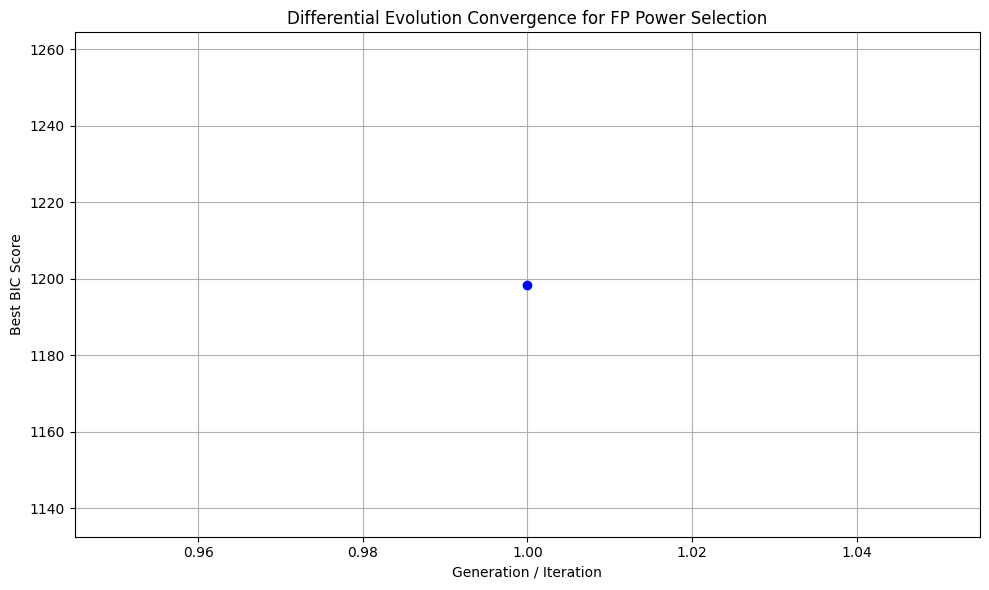


FITTING FINAL MODELS

Metric               | Traditional Cox    | FP Cox (DE Optimized)
-----------------------------------------------------------------
Concordance Index    | 0.6413             | 0.6413              
-----------------------------------------------------------------


In [12]:
# 1. Load your dataset (replace with your actual pandas dataframe)
# my_df = pd.read_csv('your_dataset.csv')
sd_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_simulated_data.csv')

# Example dummy dataset for illustration
np.random.seed(42)

# 2. Define your target columns and the covariates you want to optimize
duration_column = 'Time'
event_column = 'Event'
my_covariates = ['Age'] # Add as many as needed

# 3. Initialize and run the optimizer
optimizer = FPCoxOptimizer(
    df=sd_df, 
    covariates=my_covariates, 
    duration_col=duration_column, 
    event_col=event_column
)

# Call optimize() to run the entire pipeline
optimizer.optimize(maxiter=20, popsize=40) # Adjust iterations based on dataset size

Starting DE Optimization for 2 features...
differential_evolution step 1: f(x)= 768.4401086396165
Polishing solution with 'L-BFGS-B'

--- Optimal Power Selection ---
PatientAge: Power 1 = None, Power 2 = 0
LogNodes: Power 1 = 0.5, Power 2 = None


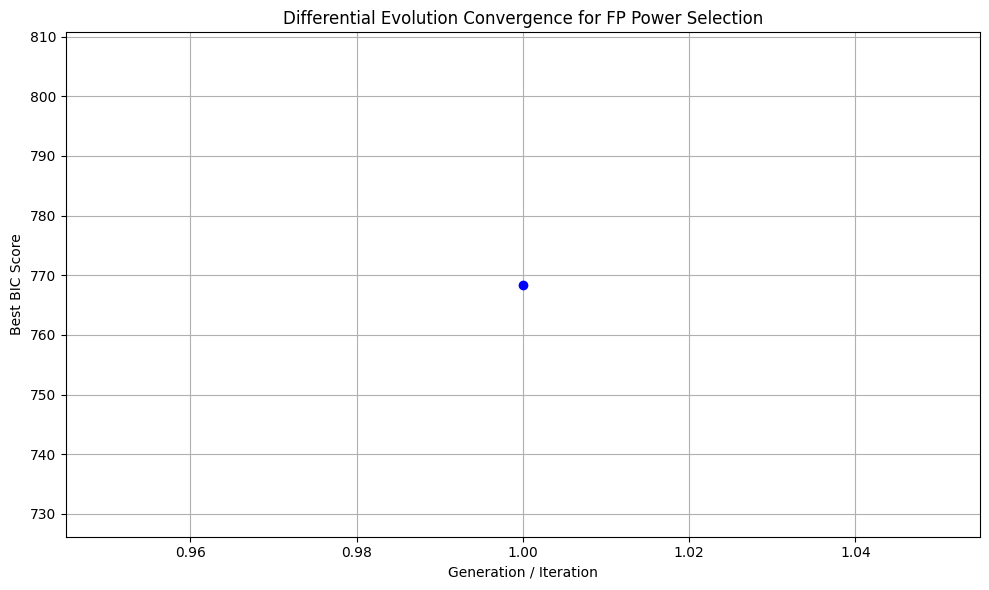


FITTING FINAL MODELS

Metric               | Traditional Cox    | FP Cox (DE Optimized)
-----------------------------------------------------------------
Concordance Index    | 0.6682             | 0.6707              
-----------------------------------------------------------------


In [13]:
# 1. Load your dataset (replace with your actual pandas dataframe)
# my_df = pd.read_csv('your_dataset.csv')
hm_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_haberman.csv')

# Example dummy dataset for illustration
np.random.seed(42)

# 2. Define your target columns and the covariates you want to optimize
duration_column = 'PatientYearOperation'
event_column = 'SurvivalStatus'
my_covariates = ['PatientAge', 'LogNodes'] # Add as many as needed

# 3. Initialize and run the optimizer
optimizer = FPCoxOptimizer(
    df=hm_df, 
    covariates=my_covariates, 
    duration_col=duration_column, 
    event_col=event_column
)

# Call optimize() to run the entire pipeline
optimizer.optimize(maxiter=20, popsize=40) # Adjust iterations based on dataset size

Starting DE Optimization for 5 features...
differential_evolution step 1: f(x)= 3484.89810326608
Polishing solution with 'L-BFGS-B'

--- Optimal Power Selection ---
log_pgr: Power 1 = 1.5, Power 2 = None
log_nodes: Power 1 = 1.5, Power 2 = -0.25
age: Power 1 = -3, Power 2 = 2
meno: Power 1 = 2.5, Power 2 = -0.25
size: Power 1 = -1, Power 2 = None


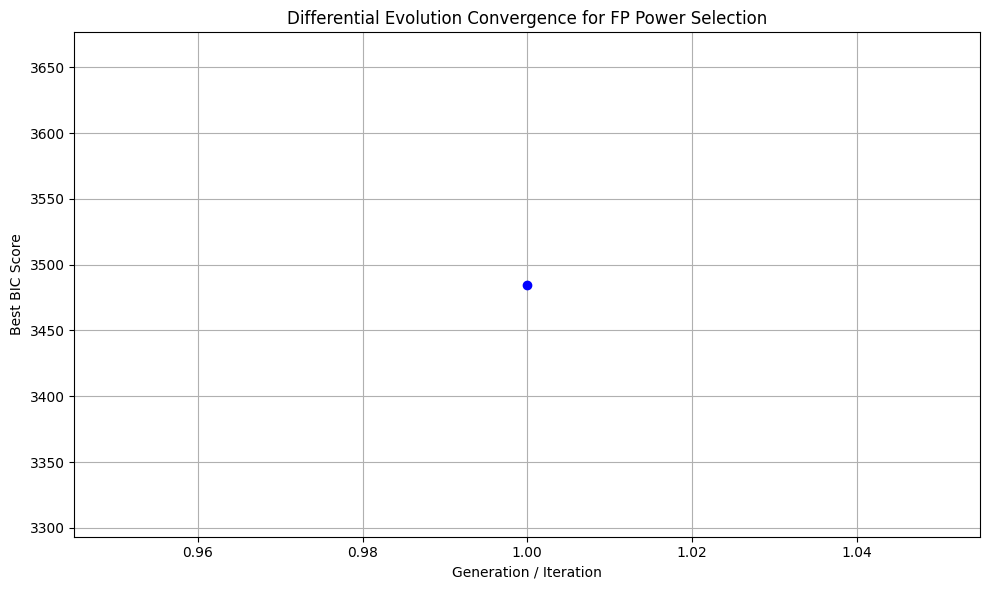


FITTING FINAL MODELS

Metric               | Traditional Cox    | FP Cox (DE Optimized)
-----------------------------------------------------------------
Concordance Index    | 0.6895             | 0.7021              
-----------------------------------------------------------------


In [15]:
# 1. Load your dataset (replace with your actual pandas dataframe)
# my_df = pd.read_csv('your_dataset.csv')
gb_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_gbsg.csv')

# Example dummy dataset for illustration
np.random.seed(42)

# 2. Define your target columns and the covariates you want to optimize
duration_column = 'rfstime'
event_column = 'status'
my_covariates = ['log_pgr', 'log_nodes', 'age', 'meno','size',] # Add as many as needed

# 3. Initialize and run the optimizer
optimizer = FPCoxOptimizer(
    df=gb_df, 
    covariates=my_covariates, 
    duration_col=duration_column, 
    event_col=event_column
)

# Call optimize() to run the entire pipeline
optimizer.optimize(maxiter=20, popsize=40) # Adjust iterations based on dataset size